In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

https://ourworldindata.org/profile/co2/united-states

In [2]:
df = pd.read_csv("emissions.csv")
emissions = df[df.Year > 1990][["Year", "Annual CO₂ emissions"]].set_index("Year").rename(columns={"Annual CO₂ emissions":"Emissions"})
emissions.head()

,Emissions
Year,
1991,5.076412e+09
1992,5.178769e+09
1993,5.279520e+09
1994,5.361863e+09
1995,5.425838e+09


In [3]:
# get percent change since 2005
net_change = emissions.copy()
ref_emission = emissions.loc[2005, "Emissions"]
net_change = net_change.loc[net_change.index >= 2000]
net_change["Change"] = net_change["Emissions"].divide(ref_emission)
net_change.head(6)

,Emissions,Change
Year,,
2000,6.023158e+09,0.983067
2001,5.903562e+09,0.963547
2002,5.947820e+09,0.970771
2003,6.006440e+09,0.980339
2004,6.111545e+09,0.997493
2005,6.126903e+09,1.000000


In [4]:
# get expected data
trend = net_change.copy()
last_year = trend.index[-1]
last_year_emissions = trend.loc[last_year, "Change"]

years = range(last_year, 2031)
trend_high = np.linspace(last_year_emissions, 0.48, len(years)) # 52% reduction
trend_low = np.linspace(last_year_emissions, 0.50, len(years)) # 50% reduction 

actual_emissions = trend.copy()[["Change"]].rename(columns={"Change":"Actual"})
high_estimate = pd.DataFrame({"Year":years, "High":trend_high}).set_index("Year")
low_estimate = pd.DataFrame({"Year":years, "Low":trend_low}).set_index("Year")
all_emissions = actual_emissions.join([low_estimate, high_estimate], how="outer")

In [5]:
# get trendline data 
last_five_years = range(last_year - 5, last_year + 1)
last_ten_years = range(last_year - 10, last_year + 1)
last_fifteen_years = range(last_year - 15, last_year + 1)

five_year_trend = trend.loc[trend.index.isin(last_five_years)]["Change"].to_numpy()
five_years = [[x] for x in last_five_years]
five_year_reg = LinearRegression().fit(five_years, five_year_trend)
five_year_value_start = five_year_reg.predict(np.array([[last_five_years[0]]]))
five_year_value_end = five_year_reg.predict(np.array([[2030]]))

ten_year_trend = trend.loc[trend.index.isin(last_ten_years)]["Change"].to_numpy()
ten_years = [[x] for x in last_ten_years]
ten_year_reg = LinearRegression().fit(ten_years, ten_year_trend)
ten_year_value_start = ten_year_reg.predict(np.array([[last_ten_years[0]]]))
ten_year_value_end = ten_year_reg.predict(np.array([[2030]]))

fifteen_year_trend = trend.loc[trend.index.isin(last_fifteen_years)]["Change"].to_numpy()
fifteen_years = [[x] for x in last_fifteen_years]
fifteen_year_reg = LinearRegression().fit(fifteen_years, fifteen_year_trend)
fifteen_year_value_start = fifteen_year_reg.predict(np.array([[last_fifteen_years[0]]]))
fifteen_year_value_end = fifteen_year_reg.predict(np.array([[2030]]))

In [6]:
# Create dataframes of trend lines
final_year = 2030
five_year_range = range(last_five_years[0], final_year + 1)
ten_year_range = range(last_ten_years[0], final_year + 1)
fifteen_year_range = range(last_fifteen_years[0], final_year + 1)
five_year_values = np.linspace(five_year_value_start[0], five_year_value_end[0], len(five_year_range))
ten_year_values = np.linspace(ten_year_value_start[0], ten_year_value_end[0], len(ten_year_range))
fifteen_year_values = np.linspace(fifteen_year_value_start[0], fifteen_year_value_end[0], len(fifteen_year_range))

df_five = pd.DataFrame({"Year":five_year_range, "5 Year Trend":five_year_values}).set_index("Year")
df_ten = pd.DataFrame({"Year":ten_year_range, "10 Year Trend":ten_year_values}).set_index("Year")
df_fifteen = pd.DataFrame({"Year":fifteen_year_range, "15 Year Trend":fifteen_year_values}).set_index("Year")

df_trends = df_five.join([df_ten, df_fifteen], how="outer").sort_index()
df_trends.tail()

,5 Year Trend,10 Year Trend,15 Year Trend
Year,,,
2026,0.791593,0.770905,0.780413
2027,0.787217,0.761219,0.772337
2028,0.782841,0.751532,0.764262
2029,0.778466,0.741845,0.756186
2030,0.774090,0.732158,0.748110


In [7]:
all_trends = all_emissions.join([df_trends]).sort_index()
all_trends = all_trends.mul(100)
all_trends = all_trends.rename(columns={
    "Actual":"Historical",
    "Low":"50% Policy Reduction",
    "High":"52% Policy Reduction",
})
all_trends

,Historical,50% Policy Reduction,52% Policy Reduction,5 Year Trend,10 Year Trend,15 Year Trend
Year,,,,,,
2000,98.306725,NaN,NaN,NaN,NaN,NaN
2001,96.354744,NaN,NaN,NaN,NaN,NaN
2002,97.077091,NaN,NaN,NaN,NaN,NaN
2003,98.033863,NaN,NaN,NaN,NaN,NaN
2004,99.749330,NaN,NaN,NaN,NaN,NaN
2005,100.000000,NaN,NaN,NaN,NaN,NaN
2006,98.668544,NaN,NaN,NaN,NaN,NaN
2007,99.912507,NaN,NaN,NaN,NaN,NaN
2008,96.610322,NaN,NaN,NaN,NaN,NaN


In [8]:
# change to reduction percentage
target_2030 = all_trends.map(lambda x: x if not x else 100 - x)
target_2030

,Historical,50% Policy Reduction,52% Policy Reduction,5 Year Trend,10 Year Trend,15 Year Trend
Year,,,,,,
2000,1.693275,NaN,NaN,NaN,NaN,NaN
2001,3.645256,NaN,NaN,NaN,NaN,NaN
2002,2.922909,NaN,NaN,NaN,NaN,NaN
2003,1.966137,NaN,NaN,NaN,NaN,NaN
2004,0.250670,NaN,NaN,NaN,NaN,NaN
2005,0.000000,NaN,NaN,NaN,NaN,NaN
2006,1.331456,NaN,NaN,NaN,NaN,NaN
2007,0.087493,NaN,NaN,NaN,NaN,NaN
2008,3.389678,NaN,NaN,NaN,NaN,NaN


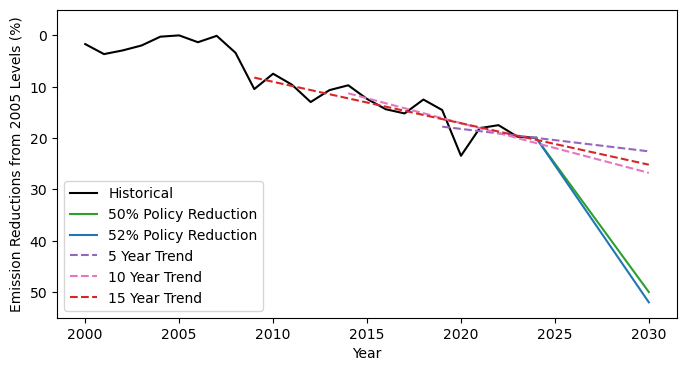

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
target_2030.plot(
    ax = ax,
    y = [
        "Historical",
        "50% Policy Reduction",
        "52% Policy Reduction",
        "5 Year Trend",
        "10 Year Trend",
        "15 Year Trend",
    ],
    style = [
        '-', 
        '-', 
        '-', 
        '--',
        '--',
        '--'
    ],
    color = [
        "black",
        "tab:green",
        "tab:blue",
        "tab:purple",
        "tab:pink",
        "tab:red"
    ]
)
ax.set_ylabel("Emission Reductions from 2005 Levels (%)")
ax.set_ylim(55, -5)
fig.savefig("2030-emissions.png", dpi=400)